# Feature Extraction

Extract image descriptors or other features for model training.

# Color Histogram Feature Extraction
**Dataset:** CUB-200-2011, first 20 bird species

## Objectives

1. Load the prepared 20-species dataset.
2. Preserve the 70% training, 15% validation and 15% testing split.
3. Implement RGB color-histogram feature extraction.
4. Visualize and review extracted histograms.
5. Extract and save color-histogram feature vectors.
6. Optionally implement Local Binary Patterns (LBP).

In [1]:
# Install the dataset downloader
!pip -q install kagglehub

from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Download the CUB-200-2011 dataset
download_path = Path(
    kagglehub.dataset_download("wenewone/cub2002011")
)

DATASET_ROOT = download_path / "CUB_200_2011"
IMAGES_FOLDER = DATASET_ROOT / "images"

print("Downloaded path:", download_path)
print("Dataset root exists:", DATASET_ROOT.exists())
print("Images folder exists:", IMAGES_FOLDER.exists())

100%|██████████| 1.49G/1.49G [00:18<00:00, 87.2MB/s]

Extracting files...


Downloaded path: /root/.cache/kagglehub/datasets/wenewone/cub2002011/versions/7
Dataset root exists: True
Images folder exists: True


In [3]:
# Load official class information
classes = pd.read_csv(
    DATASET_ROOT / "classes.txt",
    sep=r"\s+",
    names=["class_id", "class_name"]
)

# Load image IDs and relative paths
images = pd.read_csv(
    DATASET_ROOT / "images.txt",
    sep=r"\s+",
    names=["image_id", "image_path"]
)

# Load the class assigned to each image
image_labels = pd.read_csv(
    DATASET_ROOT / "image_class_labels.txt",
    sep=r"\s+",
    names=["image_id", "class_id"]
)

# Combine all metadata
metadata = images.merge(
    image_labels,
    on="image_id",
    how="inner"
)

metadata = metadata.merge(
    classes,
    on="class_id",
    how="inner"
)

print("All dataset images:", len(metadata))
print("All dataset classes:", metadata["class_id"].nunique())

display(metadata.head())

All dataset images: 11788
All dataset classes: 200


,image_id,image_path,class_id,class_name
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross


In [4]:
# Select class IDs 1 to 20, matching the team preparation notebook
selected_class_ids = (
    classes
    .sort_values("class_id")
    .head(20)["class_id"]
    .tolist()
)

metadata_20 = metadata[
    metadata["class_id"].isin(selected_class_ids)
].copy()

# Add the complete image path
metadata_20["full_image_path"] = metadata_20["image_path"].apply(
    lambda relative_path: IMAGES_FOLDER / relative_path
)

metadata_20 = (
    metadata_20
    .sort_values("image_id")
    .reset_index(drop=True)
)

existing_files = metadata_20["full_image_path"].apply(
    lambda image_path: image_path.exists()
).sum()

print("Selected classes:", metadata_20["class_id"].nunique())
print("Selected images:", len(metadata_20))
print("Existing image files:", existing_files)

print("\nSelected bird species:")
display(
    metadata_20[
        ["class_id", "class_name"]
    ].drop_duplicates()
)

Selected classes: 20
Selected images: 1115
Existing image files: 1115

Selected bird species:


,class_id,class_name
0,1,001.Black_footed_Albatross
60,2,002.Laysan_Albatross
120,3,003.Sooty_Albatross
178,4,004.Groove_billed_Ani
238,5,005.Crested_Auklet
282,6,006.Least_Auklet
323,7,007.Parakeet_Auklet
376,8,008.Rhinoceros_Auklet
424,9,009.Brewer_Blackbird
483,10,010.Red_winged_Blackbird


In [5]:
# First split: 70% training and 30% remaining
train_data, remaining_data = train_test_split(
    metadata_20,
    test_size=0.30,
    stratify=metadata_20["class_id"],
    random_state=42
)

# Second split: divide the remaining 30% equally
# into 15% validation and 15% testing
validation_data, test_data = train_test_split(
    remaining_data,
    test_size=0.50,
    stratify=remaining_data["class_id"],
    random_state=42
)

# Add split labels
metadata_20["split"] = ""

metadata_20.loc[train_data.index, "split"] = "train"
metadata_20.loc[validation_data.index, "split"] = "val"
metadata_20.loc[test_data.index, "split"] = "test"

split_counts = metadata_20["split"].value_counts()

print("Dataset split:")
print("Training images:", split_counts["train"])
print("Validation images:", split_counts["val"])
print("Testing images:", split_counts["test"])
print("Total images:", split_counts.sum())

# Confirm that every image received a split
assert (metadata_20["split"] != "").all()

print("\nEvery image received a split successfully.")

Dataset split:
Training images: 780
Validation images: 167
Testing images: 168
Total images: 1115

Every image received a split successfully.


## RGB Color Histogram Feature Extraction

A color histogram counts how many pixels belong to different intensity ranges.  
For each image, separate histograms are extracted from the red, green and blue channels.

We use:

- 32 bins for the red channel
- 32 bins for the green channel
- 32 bins for the blue channel
- 96 total features for each image

Each histogram is normalized so that images of different sizes can be compared fairly.

In [6]:
def extract_color_histogram(image_path, bins=32):
    """
    Extract a normalized RGB color histogram from one image.

    Parameters
    ----------
    image_path : str or Path
        Path of the image.
    bins : int
        Number of histogram bins for each RGB channel.

    Returns
    -------
    numpy.ndarray
        One feature vector containing:
        red histogram + green histogram + blue histogram.
    """

    # Open the image and ensure it has red, green and blue channels
    with Image.open(image_path) as image:
        image_rgb = image.convert("RGB")
        image_array = np.array(image_rgb)

    channel_histograms = []

    # Process the red, green and blue channels separately
    for channel_index in range(3):

        channel_values = image_array[:, :, channel_index]

        histogram, _ = np.histogram(
            channel_values,
            bins=bins,
            range=(0, 256)
        )

        # Convert integers to decimal numbers
        histogram = histogram.astype(np.float32)

        # Normalize the histogram
        histogram_sum = histogram.sum()

        if histogram_sum > 0:
            histogram = histogram / histogram_sum

        channel_histograms.append(histogram)

    # Join the three 32-bin histograms
    feature_vector = np.concatenate(channel_histograms)

    return feature_vector

In [7]:
# Select the first image from the prepared dataset
sample_row = metadata_20.iloc[0]
sample_image_path = sample_row["full_image_path"]

# Extract its color-histogram features
sample_histogram = extract_color_histogram(
    sample_image_path,
    bins=32
)

print("Bird species:", sample_row["class_name"])
print("Image path:", sample_row["image_path"])
print("Feature-vector length:", len(sample_histogram))
print("First 10 feature values:")
print(sample_histogram[:10])

Bird species: 001.Black_footed_Albatross
Image path: 001.Black_footed_Albatross/Black_Footed_Albatross_0046_18.jpg
Feature-vector length: 96
First 10 feature values:
[0.31579104 0.01518209 0.008      0.0102806  0.01521791 0.01840597
 0.02161791 0.02502687 0.02732537 0.02917612]


In [8]:
# Split the 96 features back into the three channels
red_histogram = sample_histogram[0:32]
green_histogram = sample_histogram[32:64]
blue_histogram = sample_histogram[64:96]

print("Red histogram sum:", round(float(red_histogram.sum()), 5))
print("Green histogram sum:", round(float(green_histogram.sum()), 5))
print("Blue histogram sum:", round(float(blue_histogram.sum()), 5))

assert len(sample_histogram) == 96
assert np.isclose(red_histogram.sum(), 1.0)
assert np.isclose(green_histogram.sum(), 1.0)
assert np.isclose(blue_histogram.sum(), 1.0)

print("\nColor-histogram function passed all checks.")

Red histogram sum: 1.0
Green histogram sum: 1.0
Blue histogram sum: 1.0

Color-histogram function passed all checks.


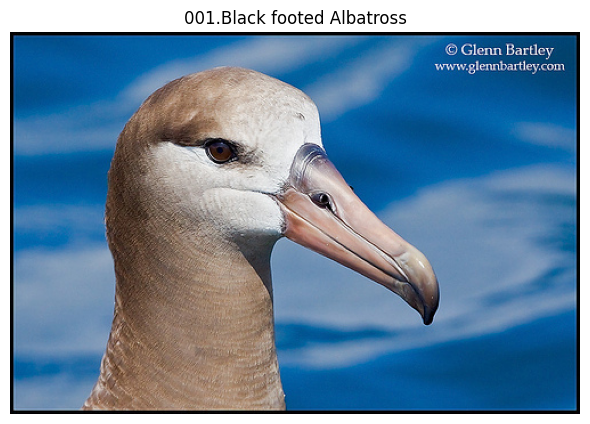

In [9]:
with Image.open(sample_image_path) as image:
    sample_image = image.convert("RGB")

plt.figure(figsize=(6, 5))
plt.imshow(sample_image)
plt.title(
    sample_row["class_name"].replace("_", " ")
)
plt.axis("off")
plt.tight_layout()
plt.show()

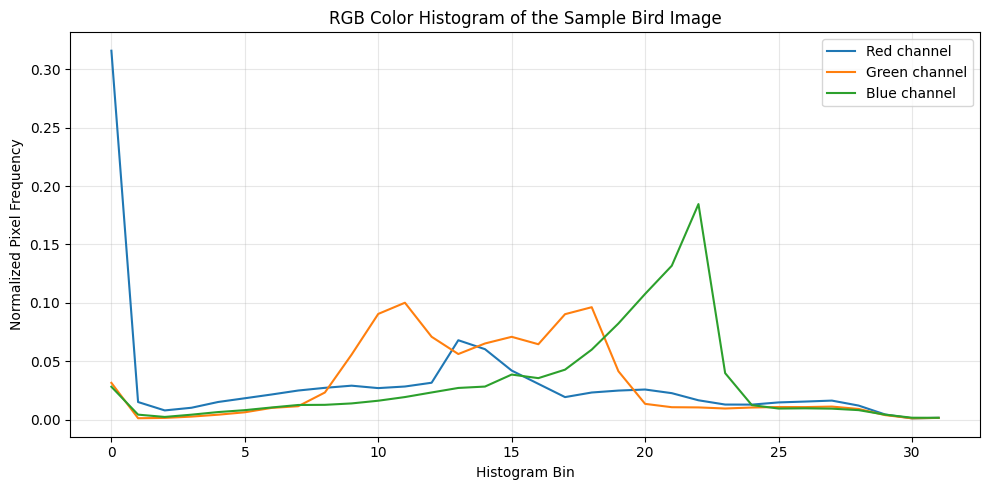

In [10]:
# The center position of each histogram bin
bin_positions = np.arange(32)

plt.figure(figsize=(10, 5))

plt.plot(
    bin_positions,
    red_histogram,
    label="Red channel"
)

plt.plot(
    bin_positions,
    green_histogram,
    label="Green channel"
)

plt.plot(
    bin_positions,
    blue_histogram,
    label="Blue channel"
)

plt.xlabel("Histogram Bin")
plt.ylabel("Normalized Pixel Frequency")
plt.title("RGB Color Histogram of the Sample Bird Image")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

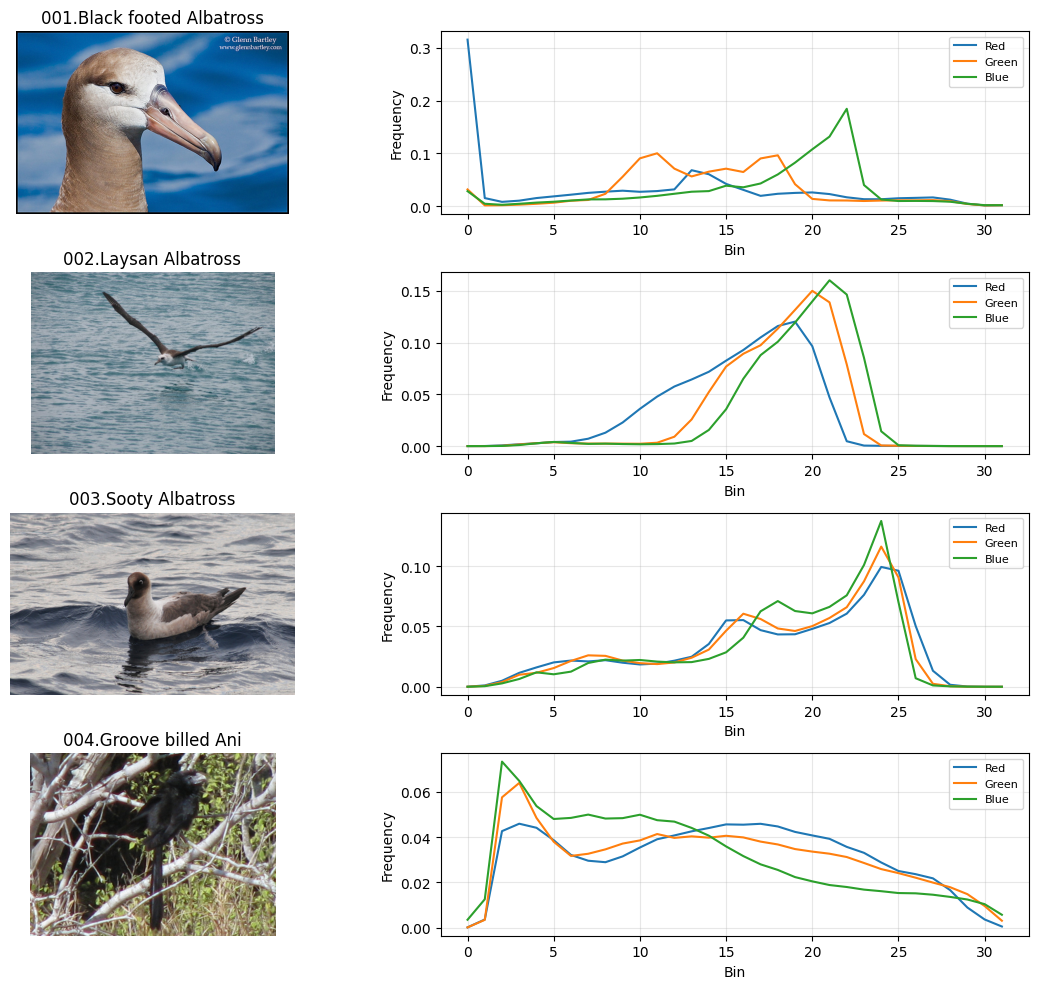

In [11]:
# Select one image from four different bird classes
sample_images = (
    metadata_20
    .groupby("class_id", group_keys=False)
    .head(1)
    .head(4)
)

plt.figure(figsize=(12, 10))

for position, (_, row) in enumerate(
    sample_images.iterrows(),
    start=1
):
    with Image.open(row["full_image_path"]) as image:
        image_rgb = image.convert("RGB")

    histogram = extract_color_histogram(
        row["full_image_path"],
        bins=32
    )

    plt.subplot(4, 2, position * 2 - 1)
    plt.imshow(image_rgb)
    plt.title(row["class_name"].replace("_", " "))
    plt.axis("off")

    plt.subplot(4, 2, position * 2)

    plt.plot(histogram[0:32], label="Red")
    plt.plot(histogram[32:64], label="Green")
    plt.plot(histogram[64:96], label="Blue")

    plt.xlabel("Bin")
    plt.ylabel("Frequency")
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Color Histogram Implementation Conclusion

An RGB color-histogram extraction function was successfully implemented. Each image is converted to RGB and represented using 32 histogram bins for each color channel. The three normalized channel histograms are concatenated to create a 96-dimensional feature vector. Testing and visualization confirmed that the function produces valid and consistent feature vectors for different bird images.